# Black-box function data explorer

This notebook compares all eight optimisation problems. It focuses on optimisation progress, output scale, input-space coverage, and relationships between individual coordinates and the observed response. Correlations are exploratory diagnostics, not proof of causal feature importance.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from scipy.spatial.distance import pdist, squareform
from scipy.stats import rankdata, spearmanr

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

DATA_DIR_NAME = 'Data'

def resolve_data_dir():
    cwd = Path.cwd()
    for root in (cwd, *cwd.parents):
        for candidate in (root / DATA_DIR_NAME, root / 'Submission Files' / DATA_DIR_NAME):
            if (candidate / 'function_1' / 'initial_inputs.npy').exists():
                return candidate
    raise FileNotFoundError(
        'Could not find Data/function_1. Run this notebook from the repository root '
        'or the Submission Files directory.'
    )


DATA_DIR = resolve_data_dir()


In [2]:
data_dir = resolve_data_dir()

# Store each function in one dictionary so later diagnostics can iterate consistently.
functions = {}
for function_id in range(1, 9):
    folder = data_dir / f'function_{function_id}'
    x = np.load(folder / 'updated_inputs.npy', allow_pickle=False)
    y = np.load(folder / 'updated_outputs.npy', allow_pickle=False).reshape(-1)
    initial_x = np.load(folder / 'initial_inputs.npy', allow_pickle=False)
    if x.ndim != 2 or len(x) != len(y):
        raise ValueError(f'Function {function_id} has inconsistent data shapes.')
    functions[function_id] = {'x': x, 'y': y, 'initial_n': len(initial_x)}

print(f'Loaded {len(functions)} functions from {data_dir.resolve()}')


Loaded 8 functions from C:\Users\Luams\Documents\GitHub\Capstone-Project\Submission Files\Data


## Dataset summary

The magnitude span is the number of orders of magnitude between the smallest and largest non-zero absolute outputs. Large spans indicate that affine standardisation alone may be inadequate.

In [3]:
header = f"{'Function':<10}{'n':>5}{'d':>5}{'New':>6}{'Min y':>15}{'Max y':>15}{'Orders':>10}  Best input"
print(header)
print('-' * len(header))
for function_id, values in functions.items():
    x, y = values['x'], values['y']
    magnitudes = np.abs(y[y != 0])
    order_span = np.ptp(np.log10(magnitudes)) if len(magnitudes) > 1 else 0.0
    best_input = np.array2string(x[np.argmax(y)], precision=3, separator=',')
    print(
        f"F{function_id:<9}{len(y):>5}{x.shape[1]:>5}{len(y)-values['initial_n']:>6}"
        f"{y.min():>15.5g}{y.max():>15.5g}{order_span:>10.1f}  {best_input}"
    )

Function      n    d   New          Min y          Max y    Orders  Best input
------------------------------------------------------------------------------
F1           23    2    13     -0.0036061      1.115e-11     152.5  [0.715,0.721]
F2           23    2    13      -0.065624        0.62963       1.7  [0.691,0.998]
F3           28    3    13       -0.45411      -0.029348       1.2  [0.988,0.502,0.079]
F4           43    4    13         -37.51        0.52574       3.2  [0.402,0.419,0.393,0.413]
F5           33    4    13        0.11294         8662.5       4.9  [1.,1.,1.,1.]
F6           33    5    13        -2.5712       -0.22425       1.1  [0.38 ,0.37 ,0.595,0.782,0.   ]
F7           43    6    13      0.0027015         2.3099       2.9  [0.064,0.236,0.709,0.173,0.307,0.725]
F8           53    8    13         5.5922         9.9658       0.3  [0.071,0.18 ,0.135,0.268,0.909,0.522,0.275,0.593]


## Optimisation progress

Each panel shows the best output available after every observation. The dashed line separates the initial design from sequential submissions. A plateau indicates that recent queries have not improved the incumbent solution.

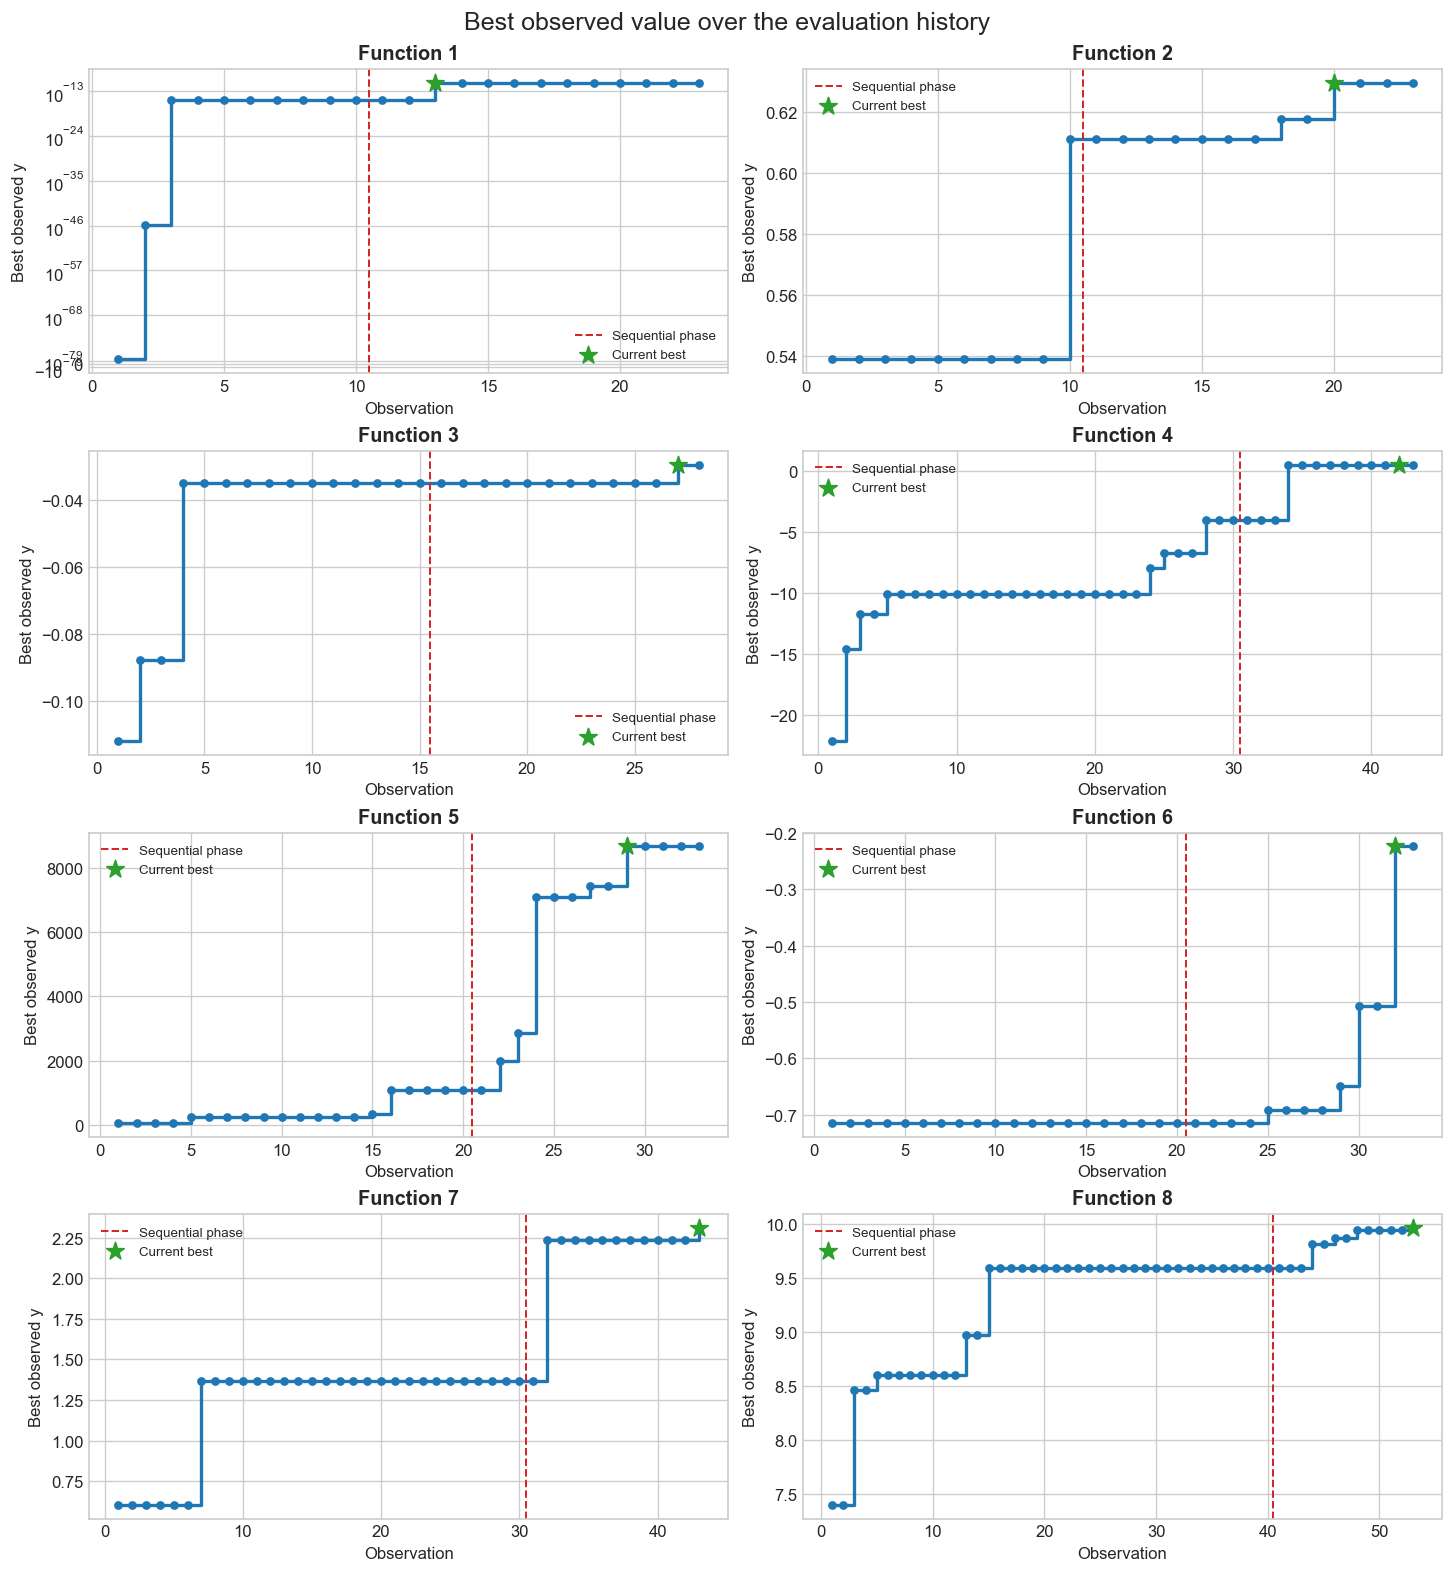

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(12, 13), constrained_layout=True)
for function_id, ax in zip(functions, axes.flat):
    values = functions[function_id]
    y = values['y']
    best_so_far = np.maximum.accumulate(y)
    observations = np.arange(1, len(y) + 1)
    ax.step(observations, best_so_far, where='post', color='C0', linewidth=2)
    ax.scatter(observations, best_so_far, color='C0', s=18)
    ax.axvline(values['initial_n'] + 0.5, color='C3', linestyle='--', linewidth=1.2, label='Sequential phase')
    ax.scatter(np.argmax(y) + 1, np.max(y), color='C2', marker='*', s=120, zorder=3, label='Current best')
    if function_id == 1:
        nonzero = np.abs(best_so_far[best_so_far != 0])
        if len(nonzero):
            ax.set_yscale('symlog', linthresh=max(nonzero.min(), np.finfo(float).tiny))
    ax.set(title=f'Function {function_id}', xlabel='Observation', ylabel='Best observed y')
    ax.legend(fontsize=8, loc='best')
fig.suptitle('Best observed value over the evaluation history', fontsize=15)
plt.show()

## Output-scale diagnostics

This view highlights functions whose outputs span many orders of magnitude. Those functions are candidates for a monotonic target transformation such as `arcsinh` or a signed logarithm before GP fitting.

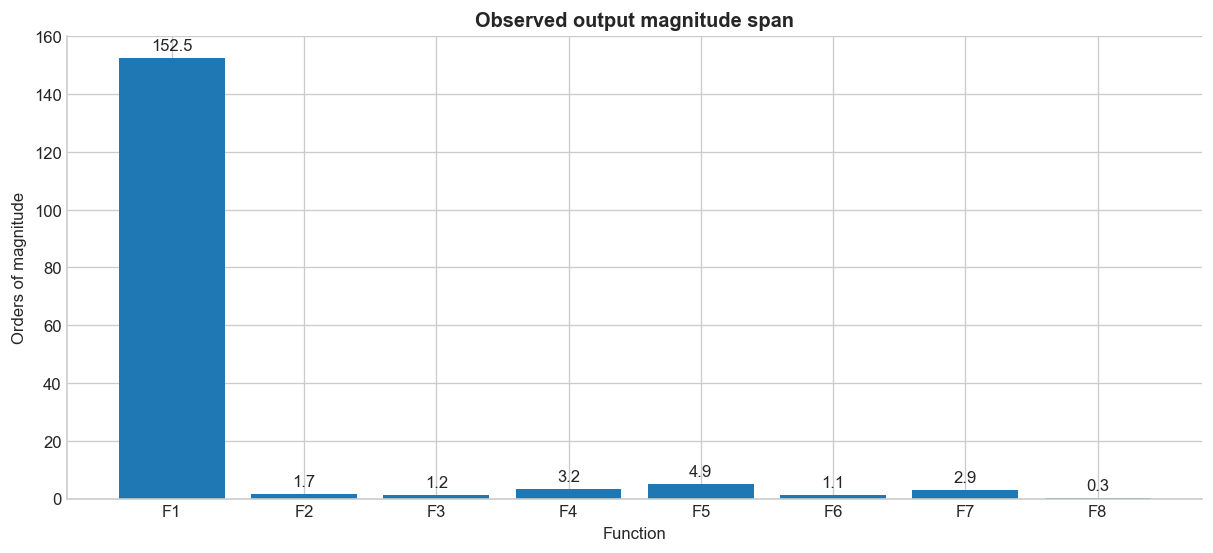

In [5]:
# Compare output scales; wide spans flag functions that may need target transforms.
order_spans = []
for values in functions.values():
    magnitudes = np.abs(values['y'][values['y'] != 0])
    order_spans.append(np.ptp(np.log10(magnitudes)) if len(magnitudes) > 1 else 0.0)

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
bars = ax.bar([f'F{i}' for i in functions], order_spans, color='C0')
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set(title='Observed output magnitude span', xlabel='Function', ylabel='Orders of magnitude')
ax.spines[['top', 'right']].set_visible(False)
plt.show()

## Coordinate-response relationships

Spearman correlation measures monotonic association and is less sensitive to output scale and extreme values than Pearson correlation. Blank cells correspond to dimensions a function does not have. Correlation can miss interactions and non-monotonic effects, so this complements rather than replaces GP length-scale diagnostics.

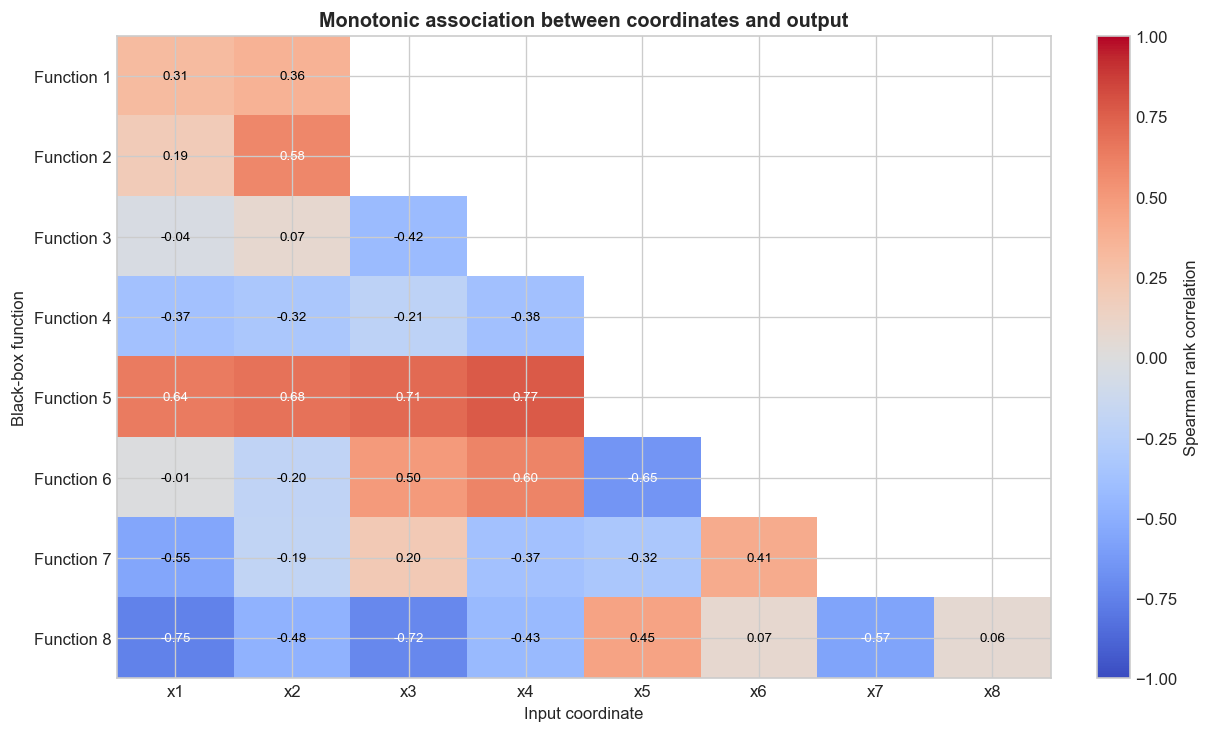

In [6]:
# Keep an 8-column grid so lower-dimensional functions align with the full search space.
correlations = np.full((8, 8), np.nan)
for function_id, values in functions.items():
    x, y = values['x'], values['y']
    for dimension in range(x.shape[1]):
        correlations[function_id - 1, dimension] = spearmanr(x[:, dimension], y).statistic

masked = np.ma.masked_invalid(correlations)
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
image = ax.imshow(masked, cmap='coolwarm', norm=Normalize(-1, 1), aspect='auto')
ax.set_xticks(range(8), [f'x{i}' for i in range(1, 9)])
ax.set_yticks(range(8), [f'Function {i}' for i in range(1, 9)])
for row in range(8):
    for column in range(8):
        value = correlations[row, column]
        if np.isfinite(value):
            ax.text(column, row, f'{value:.2f}', ha='center', va='center', color='black' if abs(value) < 0.55 else 'white', fontsize=8)
fig.colorbar(image, ax=ax, label='Spearman rank correlation')
ax.set(title='Monotonic association between coordinates and output', xlabel='Input coordinate', ylabel='Black-box function')
plt.show()

## Input-space coverage

Nearest-neighbour distance indicates how isolated each observation is. Distances are divided by `sqrt(d)` so functions of different dimensionality are more comparable. Boundary exposure shows how often coordinates are sampled within 0.05 of either edge.

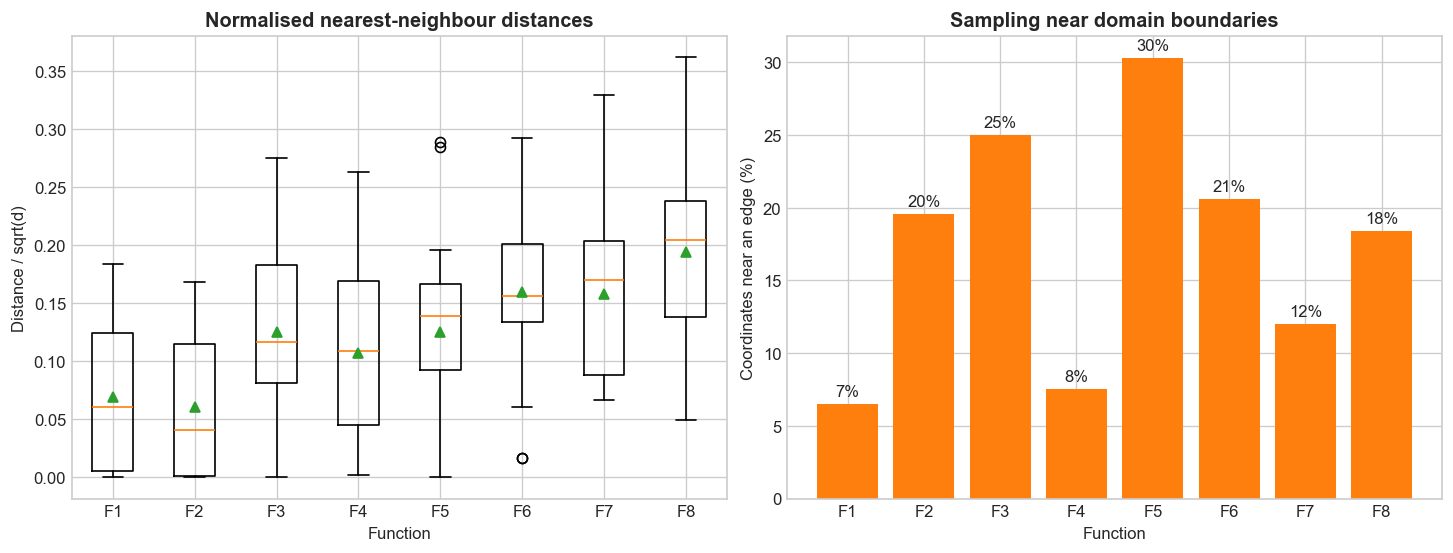

In [7]:
# Nearest-neighbour spacing and edge rates show whether sampling is clustered or boundary-heavy.
nearest_distances = []
boundary_rates = []
for values in functions.values():
    x = values['x']
    distances = squareform(pdist(x))
    np.fill_diagonal(distances, np.inf)
    nearest_distances.append(np.min(distances, axis=1) / np.sqrt(x.shape[1]))
    boundary_rates.append(np.mean((x <= 0.05) | (x >= 0.95)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].boxplot(nearest_distances, tick_labels=[f'F{i}' for i in functions], showmeans=True)
axes[0].set(title='Normalised nearest-neighbour distances', xlabel='Function', ylabel='Distance / sqrt(d)')
bars = axes[1].bar([f'F{i}' for i in functions], np.asarray(boundary_rates) * 100, color='C1')
axes[1].bar_label(bars, fmt='%.0f%%', padding=3)
axes[1].set(title='Sampling near domain boundaries', xlabel='Function', ylabel='Coordinates near an edge (%)')
plt.show()

## Detailed view of the two-dimensional functions

Colour represents output rank rather than raw magnitude, allowing Function 1's enormous dynamic range to remain visible. Stars mark the best observations and labels show collection order.

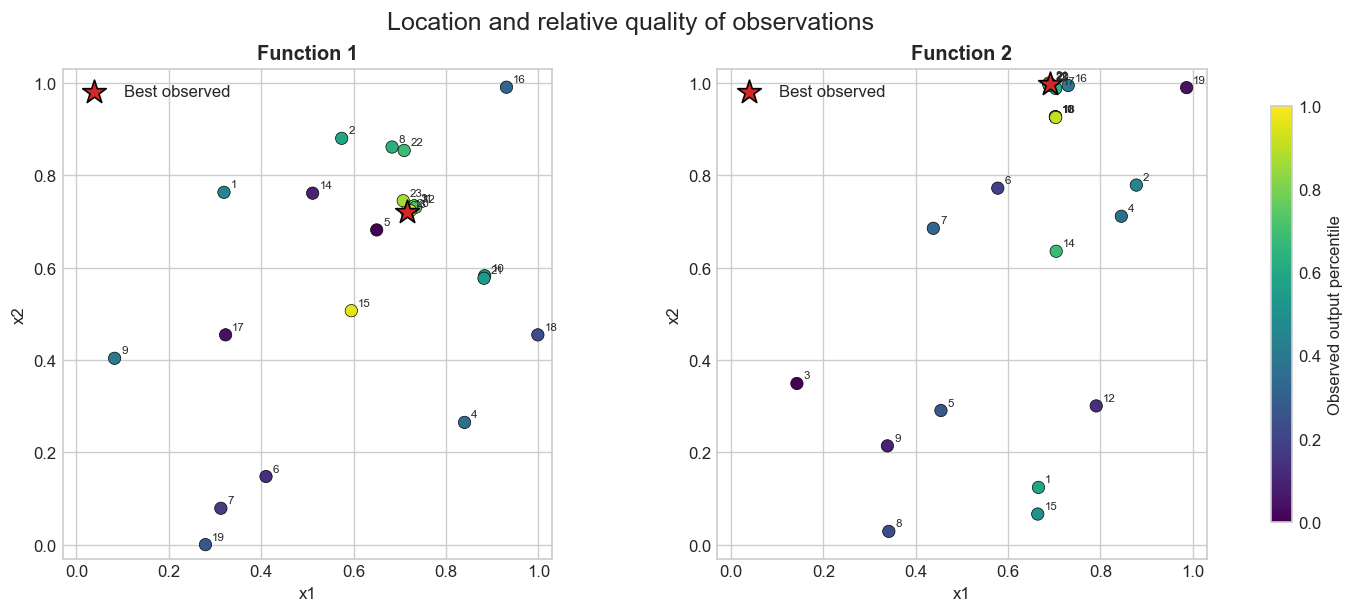

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for function_id, ax in zip((1, 2), axes):
    x, y = functions[function_id]['x'], functions[function_id]['y']
    output_percentile = (rankdata(y, method='average') - 1) / max(len(y) - 1, 1)
    points = ax.scatter(x[:, 0], x[:, 1], c=output_percentile, cmap='viridis', s=55, edgecolor='black', linewidth=0.4)
    best = np.argmax(y)
    ax.scatter(x[best, 0], x[best, 1], marker='*', s=220, color='C3', edgecolor='black', label='Best observed')
    for index, point in enumerate(x, start=1):
        ax.annotate(str(index), point, xytext=(4, 3), textcoords='offset points', fontsize=7)
    ax.set(xlim=(-0.03, 1.03), ylim=(-0.03, 1.03), title=f'Function {function_id}', xlabel='x1', ylabel='x2')
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='best')
fig.colorbar(points, ax=axes, label='Observed output percentile', shrink=0.85)
fig.suptitle('Location and relative quality of observations', fontsize=15)
plt.show()